In [280]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [281]:
path = "/content/drive/MyDrive/KNN - Hackaton/dataset_locales_comerciales_3000_AMPLIADO.csv"

In [282]:
import pandas as pd
df = pd.read_csv(path)
df.head()

,ID_Local,Rubro,Superficie_m2,Metros_Vidriera,Inversion_CAPEX_USD,Antiguedad_Anios,Inversion_Marketing_Mensual_USD,Alquiler_Mensual_USD,Transito_Peatonal_Pico,Puntos_Interes_Proximos,...,Ubicacion_Esquina,Nivel_Socioeconomico,Densidad_Poblacional_Hab_Km2,Tipo_Ubicacion,Densidad_Competencia,Venta_Online_Pct,Ticket_Promedio_USD,Posicionamiento_Precio,Margen_EBITDA_Pct,Ventas_Anuales_Totales_USD
0,1,Gastronomía,108,17.7,44306,5.2,2258,4686,886,6,...,0,C2,17966,Centro Comercial,8,0.10,41,Premium,0.23,589393
1,2,Gastronomía,90,14.0,32983,1.4,1930,3973,918,6,...,0,C3,17260,Calle Comercial,14,0.06,28,Económico,0.21,626339
2,3,Gastronomía,110,21.4,46147,13.4,1339,3206,887,5,...,1,D,21518,Calle Comercial,9,0.03,27,Económico,0.24,464248
3,4,Gastronomía,89,25.0,74669,10.1,2069,4396,860,5,...,1,C3,13637,Barrio Residencial,6,0.05,35,Medio,0.21,470543
4,5,Gastronomía,96,13.1,60644,0.3,2474,2654,949,5,...,0,C3,19960,Barrio Residencial,11,0.05,37,Medio,0.24,555527


In [283]:
df.shape
df.columns

Index(['ID_Local', 'Rubro', 'Superficie_m2', 'Metros_Vidriera',
       'Inversion_CAPEX_USD', 'Antiguedad_Anios',
       'Inversion_Marketing_Mensual_USD', 'Alquiler_Mensual_USD',
       'Transito_Peatonal_Pico', 'Puntos_Interes_Proximos',
       'Distancia_Ancla_Metros', 'Ubicacion_Esquina', 'Nivel_Socioeconomico',
       'Densidad_Poblacional_Hab_Km2', 'Tipo_Ubicacion',
       'Densidad_Competencia', 'Venta_Online_Pct', 'Ticket_Promedio_USD',
       'Posicionamiento_Precio', 'Margen_EBITDA_Pct',
       'Ventas_Anuales_Totales_USD'],
      dtype='object')

In [284]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [285]:
# Configuración
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline
print("■ Librerías cargadas correctamente")

■ Librerías cargadas correctamente


In [286]:
# Ver primeras filas

df.head()


,ID_Local,Rubro,Superficie_m2,Metros_Vidriera,Inversion_CAPEX_USD,Antiguedad_Anios,Inversion_Marketing_Mensual_USD,Alquiler_Mensual_USD,Transito_Peatonal_Pico,Puntos_Interes_Proximos,...,Ubicacion_Esquina,Nivel_Socioeconomico,Densidad_Poblacional_Hab_Km2,Tipo_Ubicacion,Densidad_Competencia,Venta_Online_Pct,Ticket_Promedio_USD,Posicionamiento_Precio,Margen_EBITDA_Pct,Ventas_Anuales_Totales_USD
0,1,Gastronomía,108,17.7,44306,5.2,2258,4686,886,6,...,0,C2,17966,Centro Comercial,8,0.10,41,Premium,0.23,589393
1,2,Gastronomía,90,14.0,32983,1.4,1930,3973,918,6,...,0,C3,17260,Calle Comercial,14,0.06,28,Económico,0.21,626339
2,3,Gastronomía,110,21.4,46147,13.4,1339,3206,887,5,...,1,D,21518,Calle Comercial,9,0.03,27,Económico,0.24,464248
3,4,Gastronomía,89,25.0,74669,10.1,2069,4396,860,5,...,1,C3,13637,Barrio Residencial,6,0.05,35,Medio,0.21,470543
4,5,Gastronomía,96,13.1,60644,0.3,2474,2654,949,5,...,0,C3,19960,Barrio Residencial,11,0.05,37,Medio,0.24,555527


In [287]:
# ver información general
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 21 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   ID_Local                         3000 non-null   int64  
 1   Rubro                            3000 non-null   object 
 2   Superficie_m2                    3000 non-null   int64  
 3   Metros_Vidriera                  3000 non-null   float64
 4   Inversion_CAPEX_USD              3000 non-null   int64  
 5   Antiguedad_Anios                 3000 non-null   float64
 6   Inversion_Marketing_Mensual_USD  3000 non-null   int64  
 7   Alquiler_Mensual_USD             3000 non-null   int64  
 8   Transito_Peatonal_Pico           3000 non-null   int64  
 9   Puntos_Interes_Proximos          3000 non-null   int64  
 10  Distancia_Ancla_Metros           3000 non-null   int64  
 11  Ubicacion_Esquina                3000 non-null   int64  
 12  Nivel_Socioeconomico

In [288]:
# Estadistica Descriptiva
df.describe()

,ID_Local,Superficie_m2,Metros_Vidriera,Inversion_CAPEX_USD,Antiguedad_Anios,Inversion_Marketing_Mensual_USD,Alquiler_Mensual_USD,Transito_Peatonal_Pico,Puntos_Interes_Proximos,Distancia_Ancla_Metros,Ubicacion_Esquina,Densidad_Poblacional_Hab_Km2,Densidad_Competencia,Venta_Online_Pct,Ticket_Promedio_USD,Margen_EBITDA_Pct,Ventas_Anuales_Totales_USD
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3.000000e+03
mean,1500.500000,95.286333,19.143333,71796.891000,5.812567,1940.346667,5880.463667,587.439667,5.501333,197.143333,0.302667,15756.426000,9.204000,0.334863,133.540000,0.253213,5.558143e+05
std,866.169729,31.743181,5.467346,27127.340332,4.341893,1205.328770,2842.731295,162.580326,1.647696,207.135268,0.459489,4683.346054,3.936185,0.201399,129.439685,0.098523,2.498558e+05
min,1.000000,30.000000,4.500000,25413.000000,0.000000,239.000000,1283.000000,254.000000,2.000000,0.000000,0.000000,5005.000000,1.000000,0.020000,12.000000,0.060000,1.156740e+05
25%,750.750000,71.000000,14.575000,52180.750000,1.700000,1098.000000,3815.500000,467.000000,4.000000,34.750000,0.000000,12478.250000,6.000000,0.170000,42.000000,0.190000,3.705148e+05
50%,1500.500000,93.000000,20.500000,66723.500000,5.100000,1661.500000,5241.500000,557.000000,6.000000,129.000000,0.000000,16081.000000,9.000000,0.310000,73.000000,0.250000,5.119570e+05
75%,2250.250000,117.000000,25.000000,85031.500000,9.300000,2465.000000,7292.500000,687.000000,7.000000,274.000000,1.000000,19287.250000,12.000000,0.470000,217.000000,0.320000,6.910908e+05
max,3000.000000,179.000000,25.000000,163977.000000,15.000000,10167.000000,21813.000000,949.000000,9.000000,797.000000,1.000000,24983.000000,19.000000,0.850000,677.000000,0.480000,1.853638e+06


In [289]:
# Ver nombres de las columnas
df.columns

Index(['ID_Local', 'Rubro', 'Superficie_m2', 'Metros_Vidriera',
       'Inversion_CAPEX_USD', 'Antiguedad_Anios',
       'Inversion_Marketing_Mensual_USD', 'Alquiler_Mensual_USD',
       'Transito_Peatonal_Pico', 'Puntos_Interes_Proximos',
       'Distancia_Ancla_Metros', 'Ubicacion_Esquina', 'Nivel_Socioeconomico',
       'Densidad_Poblacional_Hab_Km2', 'Tipo_Ubicacion',
       'Densidad_Competencia', 'Venta_Online_Pct', 'Ticket_Promedio_USD',
       'Posicionamiento_Precio', 'Margen_EBITDA_Pct',
       'Ventas_Anuales_Totales_USD'],
      dtype='object')

In [290]:
# Ver dimensiones (Filas, Columnas)
df.shape

(3000, 21)

In [291]:
# Ver todos los tipos de Datos
df.dtypes

,0
ID_Local,int64
Rubro,object
Superficie_m2,int64
Metros_Vidriera,float64
Inversion_CAPEX_USD,int64
Antiguedad_Anios,float64
Inversion_Marketing_Mensual_USD,int64
Alquiler_Mensual_USD,int64
Transito_Peatonal_Pico,int64
Puntos_Interes_Proximos,int64


In [292]:
#Limpieza de Datos. Detección de valores nulos
# Contar valores nulos por columna
nulos = df.isnull().sum()
print(nulos)


ID_Local                           0
Rubro                              0
Superficie_m2                      0
Metros_Vidriera                    0
Inversion_CAPEX_USD                0
Antiguedad_Anios                   0
Inversion_Marketing_Mensual_USD    0
Alquiler_Mensual_USD               0
Transito_Peatonal_Pico             0
Puntos_Interes_Proximos            0
Distancia_Ancla_Metros             0
Ubicacion_Esquina                  0
Nivel_Socioeconomico               0
Densidad_Poblacional_Hab_Km2       0
Tipo_Ubicacion                     0
Densidad_Competencia               0
Venta_Online_Pct                   0
Ticket_Promedio_USD                0
Posicionamiento_Precio             0
Margen_EBITDA_Pct                  0
Ventas_Anuales_Totales_USD         0
dtype: int64


In [293]:
# Porcentaje de nulos
porcentaje_nulos = (nulos / len(df)) * 100
print(porcentaje_nulos)


ID_Local                           0.0
Rubro                              0.0
Superficie_m2                      0.0
Metros_Vidriera                    0.0
Inversion_CAPEX_USD                0.0
Antiguedad_Anios                   0.0
Inversion_Marketing_Mensual_USD    0.0
Alquiler_Mensual_USD               0.0
Transito_Peatonal_Pico             0.0
Puntos_Interes_Proximos            0.0
Distancia_Ancla_Metros             0.0
Ubicacion_Esquina                  0.0
Nivel_Socioeconomico               0.0
Densidad_Poblacional_Hab_Km2       0.0
Tipo_Ubicacion                     0.0
Densidad_Competencia               0.0
Venta_Online_Pct                   0.0
Ticket_Promedio_USD                0.0
Posicionamiento_Precio             0.0
Margen_EBITDA_Pct                  0.0
Ventas_Anuales_Totales_USD         0.0
dtype: float64


In [294]:
# Detección de valores duplicados
duplicados= df.duplicated().sum()
print (f"Cantidad de duplicados: {duplicados}")

Cantidad de duplicados: 0


In [295]:
# Detección de Outliers
# Método IQR para detectar outliers
def detectar_outliers_iqr(df, columna):
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    outliers = df[(df[columna] < limite_inferior) |
                  (df[columna] > limite_superior)]
    return len(outliers)

#   Aplicar a variables numéricas
columnas_numericas = df.select_dtypes(include=[np.number]).columns
for col in columnas_numericas:
    n_outliers = detectar_outliers_iqr(df, col)
    print(f"{col}: {n_outliers} outliers")

#Inversión CAPEX: 108 outliers → Algunos locales invierten mucho más (locales premium)
#Marketing: 128 outliers → Estrategias agresivas de marketing
#Alquiler: 101 outliers → Locales en ubicaciones premium (shopping de lujo)
#Ticket Promedio: 40 outliers → Negocios de alta gama (joyerías, tecnología)
#Ventas: 66 outliers → Los locales top performers
#No los eliminaremos - ya que son casos de negocio legítimos (ej: una joyería en shopping ABC1 tendrá ventas muy superiores al promedio).

ID_Local: 0 outliers
Superficie_m2: 0 outliers
Metros_Vidriera: 0 outliers
Inversion_CAPEX_USD: 108 outliers
Antiguedad_Anios: 0 outliers
Inversion_Marketing_Mensual_USD: 128 outliers
Alquiler_Mensual_USD: 101 outliers
Transito_Peatonal_Pico: 0 outliers
Puntos_Interes_Proximos: 0 outliers
Distancia_Ancla_Metros: 204 outliers
Ubicacion_Esquina: 0 outliers
Densidad_Poblacional_Hab_Km2: 0 outliers
Densidad_Competencia: 0 outliers
Venta_Online_Pct: 0 outliers
Ticket_Promedio_USD: 40 outliers
Margen_EBITDA_Pct: 0 outliers
Ventas_Anuales_Totales_USD: 66 outliers


In [296]:
# Análisis explotatorio (EDA)
# Estadísticas de ventas
ventas = df['Ventas_Anuales_Totales_USD']
print(f"Media: ${ventas.mean():,.0f}")
print(f"Mediana: ${ventas.median():,.0f}")
print(f"Mínimo: ${ventas.min():,.0f}")
print(f"Máximo: ${ventas.max():,.0f}")


Media: $555,814
Mediana: $511,957
Mínimo: $115,674
Máximo: $1,853,638


In [297]:
# Visualizar distribución
import matplotlib.pyplot as plt

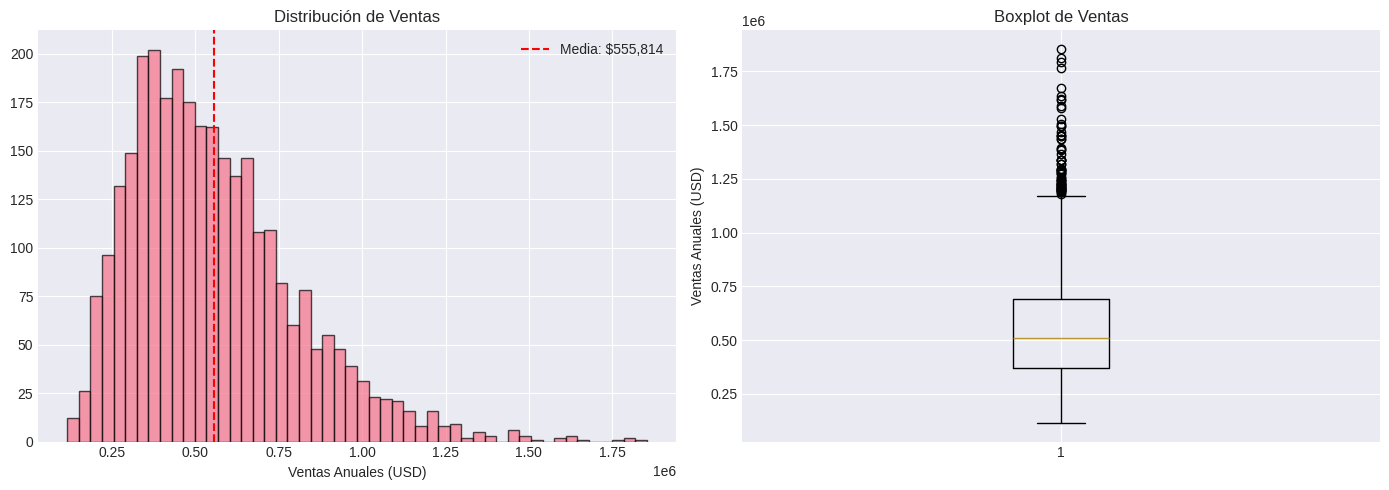

In [298]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ventas = df['Ventas_Anuales_Totales_USD']
# Histograma
axes[0].hist(ventas, bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(ventas.mean(), color='red', linestyle='--',
label=f'Media: ${ventas.mean():,.0f}')
axes[0].set_xlabel('Ventas Anuales (USD)')
axes[0].set_title('Distribución de Ventas')
axes[0].legend()
# Boxplot
axes[1].boxplot(ventas)
axes[1].set_ylabel('Ventas Anuales (USD)')
axes[1].set_title('Boxplot de Ventas')
plt.tight_layout()
plt.show()

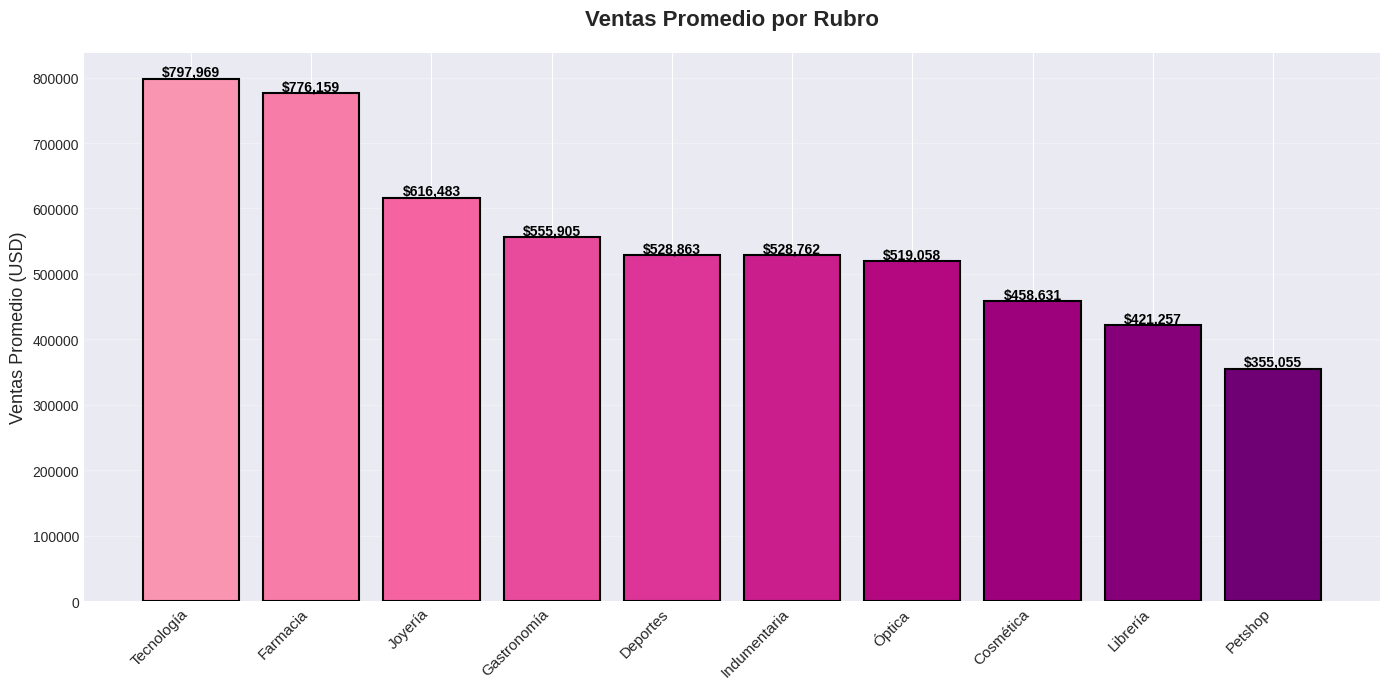

In [299]:
# Ventas promedio por rubro
ventas_rubro = df.groupby('Rubro')['Ventas_Anuales_Totales_USD'].mean().sort_values(ascending=False)

# Crear figura más grande
plt.figure(figsize=(14, 7))

# Crear degradado de colores (de oscuro a claro)
import numpy as np
colores = plt.cm.RdPu(np.linspace(0.4, 0.9, len(ventas_rubro)))
# Otras opciones de paletas: 'Blues', 'Greens', 'Oranges', 'Purples', 'viridis', 'plasma'

# Crear gráfico de barras
barras = plt.bar(range(len(ventas_rubro)), ventas_rubro.values,
                 color=colores, edgecolor='black', linewidth=1.5)

# Configurar ejes
plt.xticks(range(len(ventas_rubro)), ventas_rubro.index,
           rotation=45, ha='right', fontsize=11)
plt.ylabel('Ventas Promedio (USD)', fontsize=13)
plt.title('Ventas Promedio por Rubro', fontsize=16, fontweight='bold', pad=20)
plt.grid(True, alpha=0.3, axis='y')

# AGREGAR ETIQUETAS DE DATOS en cada barra
for i, (barra, valor) in enumerate(zip(barras, ventas_rubro.values)):
    altura = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2, altura,
             f'${valor:,.0f}',
             ha='center', va='bottom',
             fontsize=10, fontweight='bold',
             color='black')

plt.tight_layout()
plt.show()

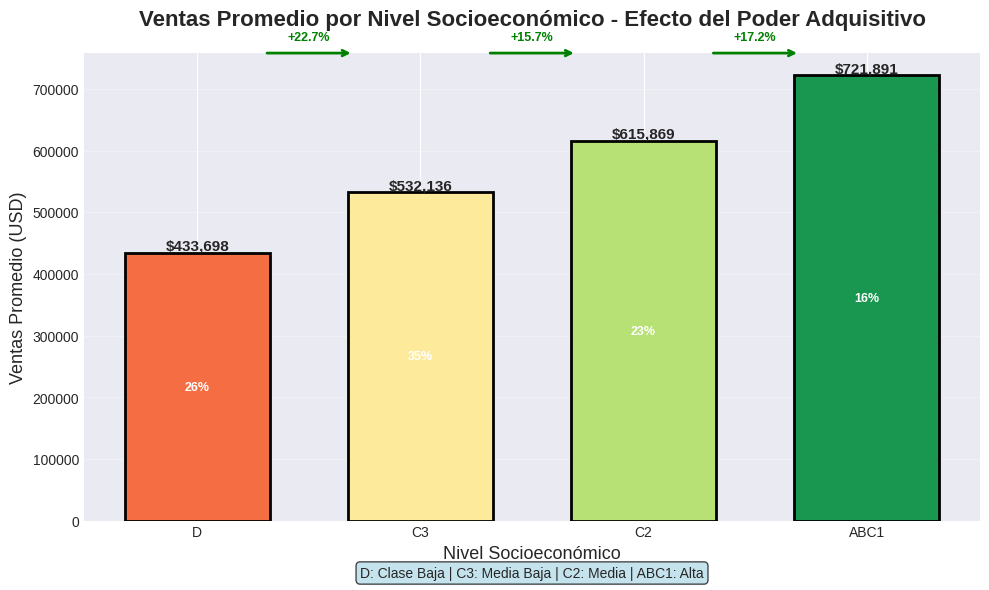

In [300]:
# Ventas promedio por nivel socioeconómico
ventas_socioeconomico = df.groupby('Nivel_Socioeconomico')['Ventas_Anuales_Totales_USD'].mean()

# Definir el orden deseado
orden_socioeconomico = ['D', 'C3', 'C2', 'ABC1']

# Reindexar para asegurar el orden y obtener los valores
ventas_ordenadas = ventas_socioeconomico.reindex(orden_socioeconomico)
orden = ventas_ordenadas.index

# Calcular porcentajes del dataset para cada nivel socioeconómico
cantidad_por_nivel = df['Nivel_Socioeconomico'].value_counts()
porcentajes = [(cantidad_por_nivel[nivel] / len(df)) * 100 for nivel in orden_socioeconomico]

# Colores degradados
import numpy as np
colores_nivel = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(orden)))

plt.figure(figsize=(10, 6))

barras = plt.bar(orden, ventas_ordenadas,
                 color=colores_nivel,
                 edgecolor='black',
                 linewidth=2,
                 width=0.65)

plt.ylabel('Ventas Promedio (USD)', fontsize=13)
plt.xlabel('Nivel Socioeconómico', fontsize=13)
plt.title('Ventas Promedio por Nivel Socioeconómico - Efecto del Poder Adquisitivo',
          fontsize=16, fontweight='bold', pad=20)
plt.grid(True, alpha=0.3, axis='y')

# Valores y porcentajes
for i, (barra, nivel, valor, pct) in enumerate(zip(barras, orden, ventas_ordenadas, porcentajes)):
    altura = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2, altura,
             f'${valor:,.0f}',
             ha='center', va='bottom',
             fontsize=11, fontweight='bold')

    plt.text(barra.get_x() + barra.get_width()/2, altura * 0.5,
             f'{pct:.0f}%',
             ha='center', va='center',
             fontsize=9, color='white', fontweight='bold')

# FLECHAS mostrando incremento entre niveles
for i in range(len(orden)-1):
    x_inicio = i + 0.3
    x_fin = i + 0.7
    y_pos = max(ventas_ordenadas) * 1.05

    incremento_pct = ((ventas_ordenadas[i+1] - ventas_ordenadas[i]) / ventas_ordenadas[i]) * 100

    plt.annotate('', xy=(x_fin, y_pos), xytext=(x_inicio, y_pos),
                arrowprops=dict(arrowstyle='->', lw=2, color='green'))

    plt.text((x_inicio + x_fin) / 2, y_pos * 1.02,
             f'+{incremento_pct:.1f}%',
             ha='center', va='bottom',
             fontsize=9, color='green', fontweight='bold')

# Leyenda informativa
leyenda_texto = """D: Clase Baja | C3: Media Baja | C2: Media | ABC1: Alta"""
plt.text(0.5, -0.12, leyenda_texto,
         transform=plt.gca().transAxes,
         fontsize=10,
         ha='center',
         bbox=dict(boxstyle='round', facecolor='lightblue',
                  alpha=0.7, edgecolor='black'))

plt.tight_layout()
plt.show()

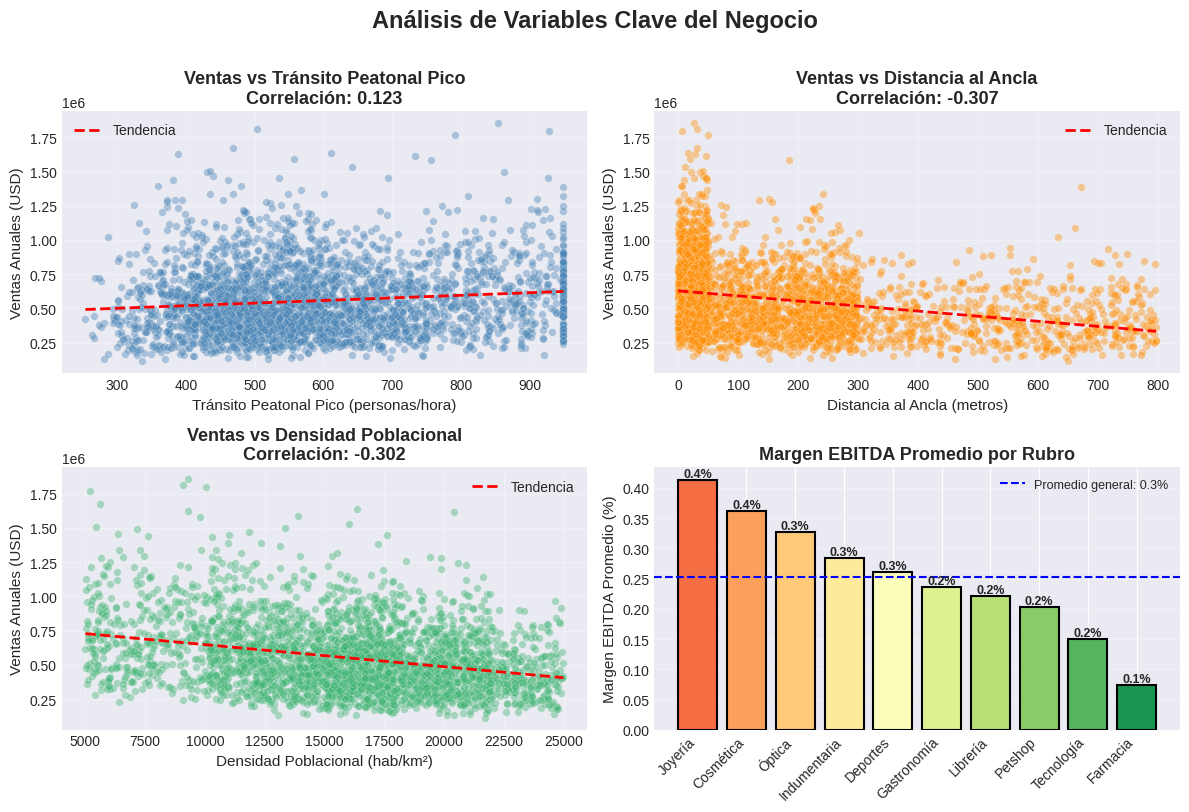

In [301]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# ── 1. VENTAS x TRÁNSITO PEATONAL PICO ──────────────────────────────
axes[0,0].scatter(df['Transito_Peatonal_Pico'],
                  df['Ventas_Anuales_Totales_USD'],
                  alpha=0.4, s=30, color='steelblue', edgecolor='white', linewidth=0.3)

z = np.polyfit(df['Transito_Peatonal_Pico'], df['Ventas_Anuales_Totales_USD'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['Transito_Peatonal_Pico'].min(), df['Transito_Peatonal_Pico'].max(), 100)
axes[0,0].plot(x_line, p(x_line), color='red', linestyle='--', linewidth=2, label='Tendencia')

corr_transito = df['Transito_Peatonal_Pico'].corr(df['Ventas_Anuales_Totales_USD'])
axes[0,0].set_xlabel('Tránsito Peatonal Pico (personas/hora)', fontsize=11)
axes[0,0].set_ylabel('Ventas Anuales (USD)', fontsize=11)
axes[0,0].set_title(f'Ventas vs Tránsito Peatonal Pico\nCorrelación: {corr_transito:.3f}',
                     fontsize=13, fontweight='bold')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# ── 2. VENTAS x DISTANCIA AL ANCLA ──────────────────────────────────
axes[0,1].scatter(df['Distancia_Ancla_Metros'],
                  df['Ventas_Anuales_Totales_USD'],
                  alpha=0.4, s=30, color='darkorange', edgecolor='white', linewidth=0.3)

z2 = np.polyfit(df['Distancia_Ancla_Metros'], df['Ventas_Anuales_Totales_USD'], 1)
p2 = np.poly1d(z2)
x_line2 = np.linspace(df['Distancia_Ancla_Metros'].min(), df['Distancia_Ancla_Metros'].max(), 100)
axes[0,1].plot(x_line2, p2(x_line2), color='red', linestyle='--', linewidth=2, label='Tendencia')

corr_ancla = df['Distancia_Ancla_Metros'].corr(df['Ventas_Anuales_Totales_USD'])
axes[0,1].set_xlabel('Distancia al Ancla (metros)', fontsize=11)
axes[0,1].set_ylabel('Ventas Anuales (USD)', fontsize=11)
axes[0,1].set_title(f'Ventas vs Distancia al Ancla\nCorrelación: {corr_ancla:.3f}',
                     fontsize=13, fontweight='bold')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)


# ── 3. VENTAS x DENSIDAD POBLACIONAL ────────────────────────────────
axes[1,0].scatter(df['Densidad_Poblacional_Hab_Km2'],
                  df['Ventas_Anuales_Totales_USD'],
                  alpha=0.4, s=30, color='mediumseagreen', edgecolor='white', linewidth=0.3)

z3 = np.polyfit(df['Densidad_Poblacional_Hab_Km2'], df['Ventas_Anuales_Totales_USD'], 1)
p3 = np.poly1d(z3)
x_line3 = np.linspace(df['Densidad_Poblacional_Hab_Km2'].min(), df['Densidad_Poblacional_Hab_Km2'].max(), 100)
axes[1,0].plot(x_line3, p3(x_line3), color='red', linestyle='--', linewidth=2, label='Tendencia')

corr_densidad = df['Densidad_Poblacional_Hab_Km2'].corr(df['Ventas_Anuales_Totales_USD'])
axes[1,0].set_xlabel('Densidad Poblacional (hab/km²)', fontsize=11)
axes[1,0].set_ylabel('Ventas Anuales (USD)', fontsize=11)
axes[1,0].set_title(f'Ventas vs Densidad Poblacional\nCorrelación: {corr_densidad:.3f}',
                     fontsize=13, fontweight='bold')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# ── 4. MARGEN EBITDA POR RUBRO ───────────────────────────────────────
ebitda_rubro = df.groupby('Rubro')['Margen_EBITDA_Pct'].mean().sort_values(ascending=False)

colores_ebitda = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(ebitda_rubro)))
barras = axes[1,1].bar(range(len(ebitda_rubro)), ebitda_rubro.values,
                        color=colores_ebitda, edgecolor='black', linewidth=1.5)

axes[1,1].set_xticks(range(len(ebitda_rubro)))
axes[1,1].set_xticklabels(ebitda_rubro.index, rotation=45, ha='right', fontsize=10)
axes[1,1].set_ylabel('Margen EBITDA Promedio (%)', fontsize=11)
axes[1,1].set_title('Margen EBITDA Promedio por Rubro', fontsize=13, fontweight='bold')
axes[1,1].grid(True, alpha=0.3, axis='y')
axes[1,1].axhline(y=ebitda_rubro.mean(), color='blue', linestyle='--',
                   linewidth=1.5, label=f'Promedio general: {ebitda_rubro.mean():.1f}%')
axes[1,1].legend(fontsize=9)

for barra, valor in zip(barras, ebitda_rubro.values):
    axes[1,1].text(barra.get_x() + barra.get_width()/2, valor,
                   f'{valor:.1f}%', ha='center', va='bottom',
                   fontsize=9, fontweight='bold')

plt.suptitle('Análisis de Variables Clave del Negocio',
             fontsize=17, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()





In [302]:
# Análisis cruzado: Ubicación + Nivel Socioeconómico
print("\n" + "="*80)
print("ANÁLISIS CRUZADO: UBICACIÓN × NIVEL SOCIOECONÓMICO")
print("="*80)

tabla_cruzada = df.groupby(['Tipo_Ubicacion', 'Nivel_Socioeconomico'])['Ventas_Anuales_Totales_USD'].mean()
print(tabla_cruzada.unstack().round(0))

# Define ventas_ubicacion before it is used
ventas_ubicacion = df.groupby('Tipo_Ubicacion')['Ventas_Anuales_Totales_USD'].mean().sort_values(ascending=False)

print("\n💡 Combinación ÓPTIMA: Shopping + ABC1")
if 'Shopping' in ventas_ubicacion.index:
    mejor_combo = df[(df['Tipo_Ubicacion'] == 'Shopping') &
                     (df['Nivel_Socioeconomico'] == 'ABC1')]['Ventas_Anuales_Totales_USD'].mean()
    print(f"   Ventas promedio: ${mejor_combo:,.0f}")


ANÁLISIS CRUZADO: UBICACIÓN × NIVEL SOCIOECONÓMICO
Nivel_Socioeconomico      ABC1        C2        C3         D
Tipo_Ubicacion                                              
Barrio Residencial    559010.0  506001.0  425704.0  370451.0
Calle Comercial       677569.0  571402.0  514729.0  448936.0
Centro Comercial      748582.0  658117.0  598473.0  512412.0
Shopping              875528.0  750588.0  700086.0  587628.0

💡 Combinación ÓPTIMA: Shopping + ABC1
   Ventas promedio: $875,528


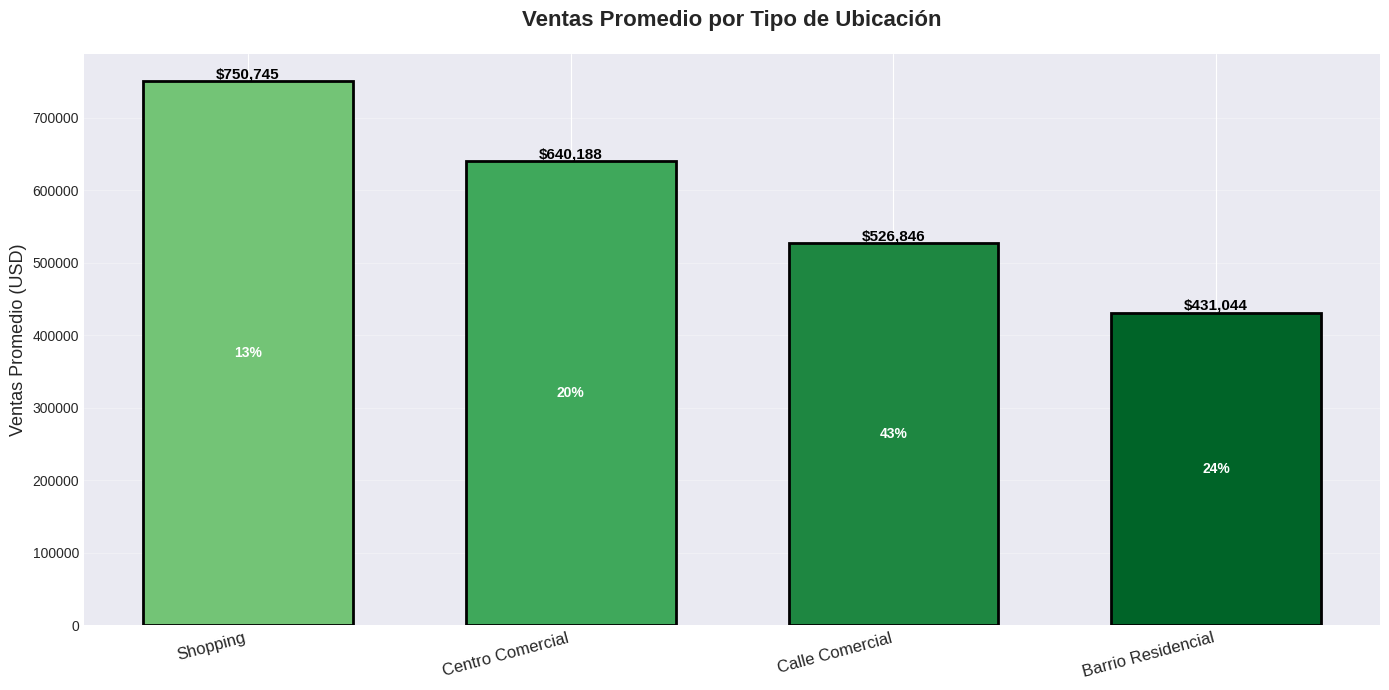

In [303]:
# Ventas promedio por tipo de ubicación
ventas_ubicacion = df.groupby('Tipo_Ubicacion')['Ventas_Anuales_Totales_USD'].mean().sort_values(ascending=False)

# Contar locales por tipo
cantidad_por_ubicacion = df['Tipo_Ubicacion'].value_counts()
porcentajes_ub = [(cantidad_por_ubicacion[ub] / len(df)) * 100 for ub in ventas_ubicacion.index]

# Crear figura
plt.figure(figsize=(14, 7))

# Colores degradados
import numpy as np
colores_ubicacion = plt.cm.Greens(np.linspace(0.5, 0.9, len(ventas_ubicacion)))

# Crear gráfico de barras
barras = plt.bar(range(len(ventas_ubicacion)), ventas_ubicacion.values,
                 color=colores_ubicacion,
                 edgecolor='black',
                 linewidth=2,
                 width=0.65)

# Configurar ejes
plt.xticks(range(len(ventas_ubicacion)), ventas_ubicacion.index,
           rotation=15, ha='right', fontsize=12)
plt.ylabel('Ventas Promedio (USD)', fontsize=13)
plt.title('Ventas Promedio por Tipo de Ubicación',
          fontsize=16, fontweight='bold', pad=20)
plt.grid(True, alpha=0.3, axis='y')

# ETIQUETAS DE VALORES
for i, (barra, valor, pct) in enumerate(zip(barras, ventas_ubicacion.values, porcentajes_ub)):
    altura = barra.get_height()

    # Valor de ventas (encima)
    plt.text(barra.get_x() + barra.get_width()/2, altura,
             f'${valor:,.0f}',
             ha='center', va='bottom',
             fontsize=11, fontweight='bold',
             color='black')

    # Porcentaje del dataset (dentro)
    plt.text(barra.get_x() + barra.get_width()/2, altura * 0.5,
             f'{pct:.0f}%',
             ha='center', va='center',
             fontsize=10,
             color='white',
             fontweight='bold')

plt.tight_layout()
plt.show()

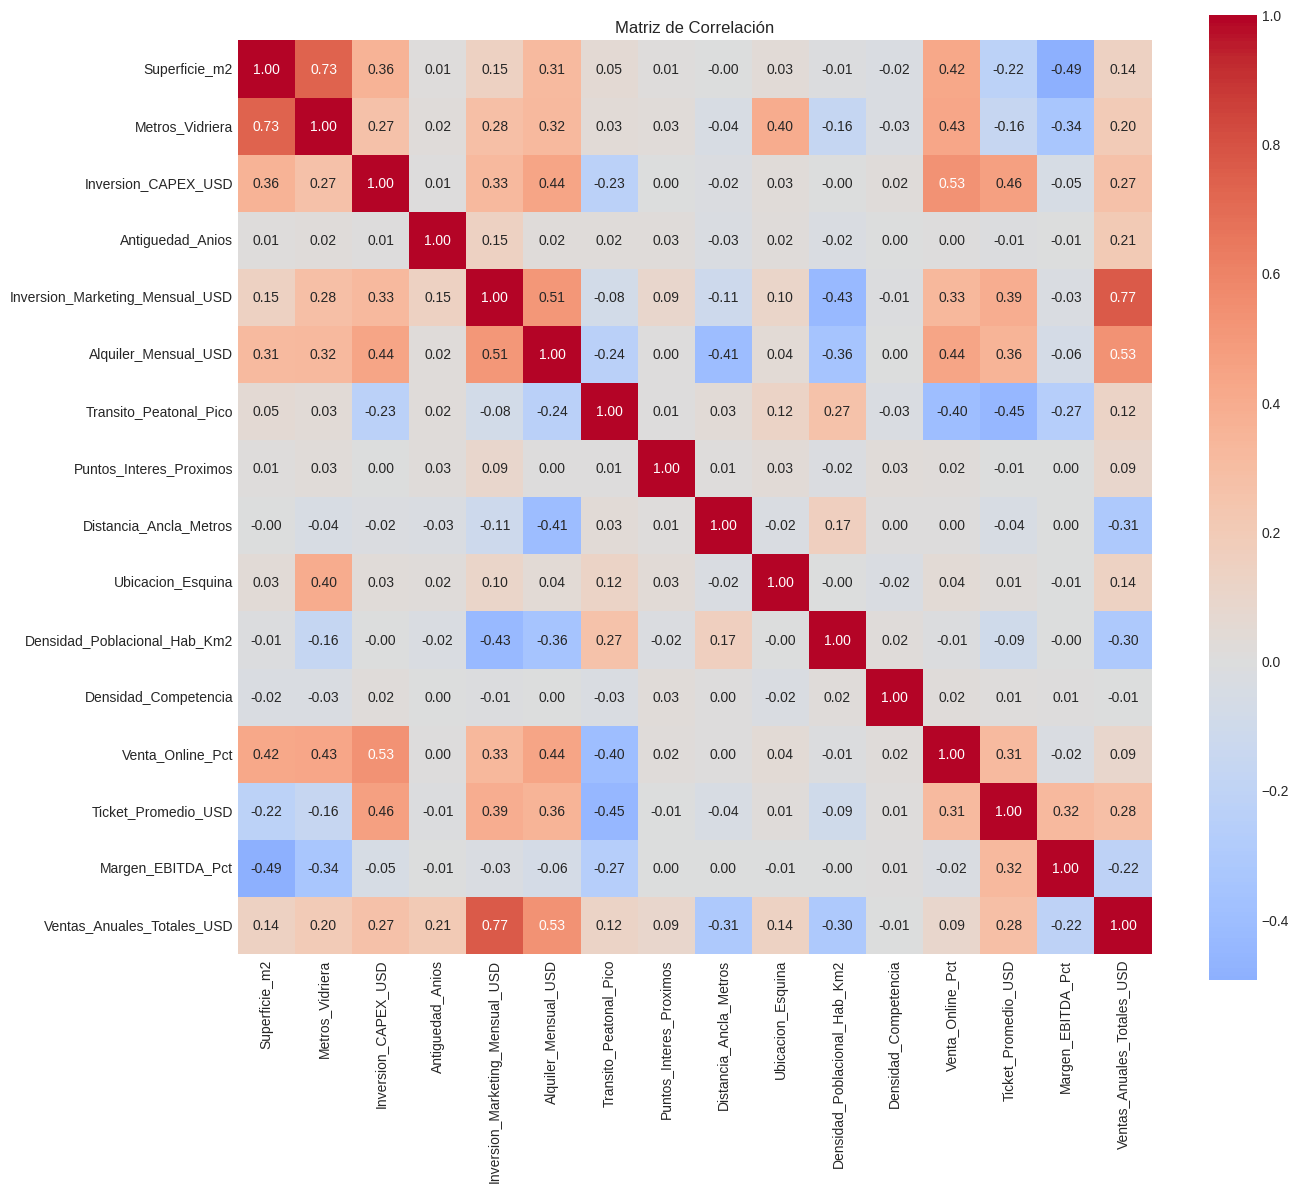

In [304]:
import numpy as np
import seaborn as sns
# Matriz de correlación

df_numerico = df.select_dtypes(include=[np.number])

# eliminar ID
df_numerico = df_numerico.drop(columns=["ID_Local"], errors="ignore")

correlacion = df_numerico.corr()

plt.figure(figsize=(14, 12))
sns.heatmap(correlacion, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True)
plt.title('Matriz de Correlación')
plt.tight_layout()
plt.show()

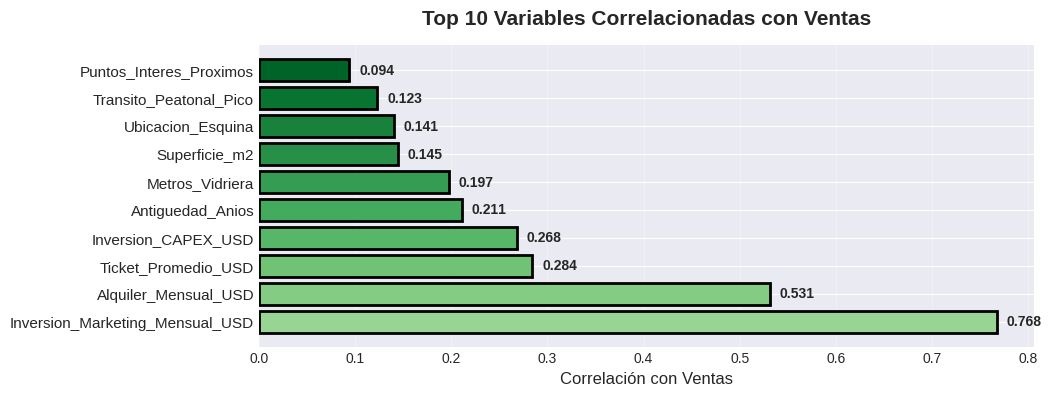

In [305]:
# Calcular correlaciones con Ventas
df_numerico = df.select_dtypes(include=[np.number])
correlacion = df_numerico.corr()
corr_ventas = correlacion['Ventas_Anuales_Totales_USD'].drop('Ventas_Anuales_Totales_USD').sort_values(ascending=False)

# Top 10
top_10 = corr_ventas.head(10)

# Crear figura con subplots
fig = plt.figure(figsize=(10, 6))
gs = fig.add_gridspec(2, 1, height_ratios=[3, 1], hspace=0.3)

# ========== GRÁFICO DE BARRAS ==========
ax1 = fig.add_subplot(gs[0])

colores = plt.cm.Greens(np.linspace(0.4, 0.9, len(top_10)))

barras = ax1.barh(range(len(top_10)), top_10.values,
                  color=colores,
                  edgecolor='black',
                  linewidth=2)

ax1.set_yticks(range(len(top_10)))
ax1.set_yticklabels(top_10.index, fontsize=11)
ax1.set_xlabel('Correlación con Ventas', fontsize=12)
ax1.set_title('Top 10 Variables Correlacionadas con Ventas',
              fontsize=15, fontweight='bold', pad=15)
ax1.grid(True, alpha=0.3, axis='x')

# Agregar valores en las barras
for i, (barra, valor) in enumerate(zip(barras, top_10.values)):
    ax1.text(valor + 0.01, i, f'{valor:.3f}',
             va='center', fontsize=10, fontweight='bold')



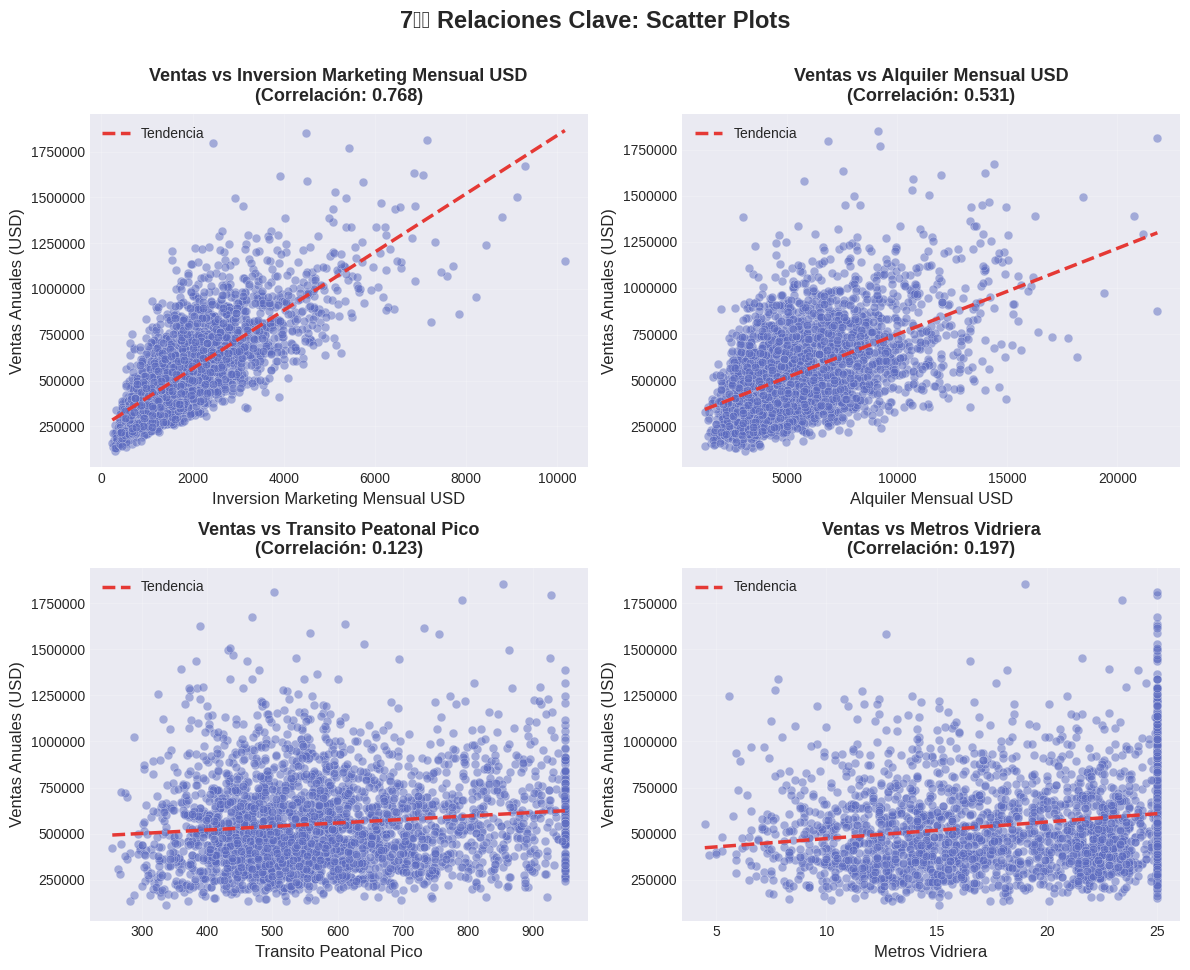

In [306]:
# Calcular correlaciones
df_numerico = df.select_dtypes(include=[np.number])
correlacion = df_numerico.corr()
corr_ventas = correlacion['Ventas_Anuales_Totales_USD'].drop('Ventas_Anuales_Totales_USD').sort_values(ascending=False)

# Seleccionar las 4 variables MÁS IMPORTANTES que tengan sentido de negocio
# Variables que SÍ impactan y que el negocio puede controlar o son relevantes
variables_clave = []

# 1. Inversión en Marketing (la más fuerte)
if 'Inversion_Marketing_Mensual_USD' in corr_ventas.index:
    variables_clave.append('Inversion_Marketing_Mensual_USD')

# 2. Alquiler (ubicación premium)
if 'Alquiler_Mensual_USD' in corr_ventas.index:
    variables_clave.append('Alquiler_Mensual_USD')

# 3. Tránsito Peatonal (muy importante para ventas)
if 'Transito_Peatonal_Pico' in corr_ventas.index:
    variables_clave.append('Transito_Peatonal_Pico')

# 4. Metros de Vidriera (visibilidad)
if 'Metros_Vidriera' in corr_ventas.index:
    variables_clave.append('Metros_Vidriera')

# Si no completamos 4, agregar las siguientes del top
while len(variables_clave) < 4 and len(variables_clave) < len(corr_ventas):
    siguiente = corr_ventas.index[len(variables_clave)]
    if siguiente not in variables_clave:
        variables_clave.append(siguiente)

# Tomar solo las primeras 4
variables_clave = variables_clave[:4]

# Crear figura con 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

# Colores
color_puntos = '#5c6bc0'
color_linea = '#e53935'

for idx, var in enumerate(variables_clave):
    # Scatter plot
    axes[idx].scatter(df[var], df['Ventas_Anuales_Totales_USD'],
                     alpha=0.5, s=40, color=color_puntos,
                     edgecolor='white', linewidth=0.3)

    # Línea de tendencia
    z = np.polyfit(df[var], df['Ventas_Anuales_Totales_USD'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[var].min(), df[var].max(), 100)
    axes[idx].plot(x_line, p(x_line), color=color_linea,
                   linestyle='--', linewidth=2.5, label='Tendencia')

    # Título con correlación
    corr_valor = corr_ventas[var]
    axes[idx].set_xlabel(var.replace('_', ' '), fontsize=12)
    axes[idx].set_ylabel('Ventas Anuales (USD)', fontsize=12)
    axes[idx].set_title(f'Ventas vs {var.replace("_", " ")}\n(Correlación: {corr_valor:.3f})',
                       fontsize=13, fontweight='bold', pad=10)
    axes[idx].legend(loc='upper left', fontsize=10)
    axes[idx].grid(True, alpha=0.2)

    # Formato de números en ejes
    axes[idx].ticklabel_format(style='plain', axis='both')

# Título general
fig.suptitle('7️⃣ Relaciones Clave: Scatter Plots',
             fontsize=17, fontweight='bold', x=0.5, y=0.995)

plt.tight_layout(rect=[0, 0.03, 1, 0.99])

#■ Interpretación: Las líneas rojas muestran la tendencia. Una pendiente positiva confirma que al aumentar la variable X, aumentan las ventas.
#ANÁLISIS DE VARIABLES CLAVE QUE IMPACTAN LAS VENTAS
#================================================================================
#1. INVERSION MARKETING MENSUAL USD
#  Correlación con Ventas: +0.768
#  Promedio en dataset: 1,940.3
#  💡 A mayor inversión en marketing, mayores ventas (relación muy fuerte)
#2. ALQUILER MENSUAL USD
#  Correlación con Ventas: +0.531
#  Promedio en dataset: 5,880.5
#  💡 Alquiler alto indica ubicación premium = más tráfico = más ventas
#3. TRANSITO PEATONAL PICO
#Correlación con Ventas: +0.123
#  Promedio en dataset: 587.4
#  💡 Más tráfico peatonal = mayor exposición = más ventas
#4. METROS VIDRIERA
#  Correlación con Ventas: +0.197
#  Promedio en dataset: 19.1
#  💡 Más metros de vidriera = mayor visibilidad = más ventas
##================================================================================#

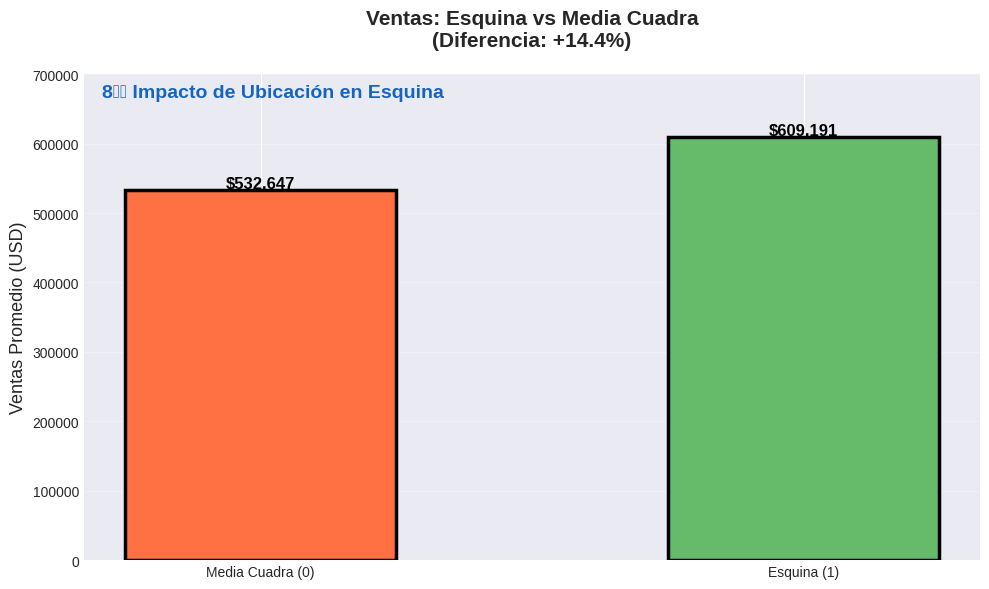

IMPACTO DE UBICACIÓN EN ESQUINA
Media Cuadra (0): $     532,647
Esquina (1):      $     609,191
----------------------------------------------------------------------
Diferencia:       $      76,544
Incremento:               14.4%

📊 Distribución en el dataset:
   Media cuadra: 2092 locales (69.7%)
   Esquina: 908 locales (30.3%)


In [307]:
# Ventas por ubicación en esquina
ventas_esquina = df.groupby('Ubicacion_Esquina')['Ventas_Anuales_Totales_USD'].mean()

# Calcular diferencia porcentual
diferencia_pct = ((ventas_esquina[1] - ventas_esquina[0]) / ventas_esquina[0]) * 100

# Crear figura
plt.figure(figsize=(10, 6))

# Datos
labels = ['Media Cuadra (0)', 'Esquina (1)']
valores = [ventas_esquina[0], ventas_esquina[1]]
colores = ['#ff7043', '#66bb6a']

# Crear barras
barras = plt.bar(labels, valores,
                 color=colores,
                 edgecolor='black',
                 linewidth=2.5,
                 width=0.5)

# Configurar ejes
plt.ylabel('Ventas Promedio (USD)', fontsize=13)
plt.title(f'Ventas: Esquina vs Media Cuadra\n(Diferencia: +{diferencia_pct:.1f}%)',
          fontsize=15, fontweight='bold', pad=20)
plt.grid(True, alpha=0.3, axis='y')
plt.ylim(0, max(valores) * 1.15)

# Agregar valores encima de las barras
for barra, valor in zip(barras, valores):
    plt.text(barra.get_x() + barra.get_width()/2, valor,
             f'${valor:,.0f}',
             ha='center', va='bottom',
             fontsize=12, fontweight='bold',
             color='black')

# Título del gráfico
plt.text(0.02, 0.98, '8️⃣ Impacto de Ubicación en Esquina',
         transform=plt.gca().transAxes,
         fontsize=14,
         fontweight='bold',
         color='#1565c0',
         verticalalignment='top')

plt.tight_layout()
plt.show()

# Estadísticas
print("="*70)
print("IMPACTO DE UBICACIÓN EN ESQUINA")
print("="*70)
print(f"Media Cuadra (0): ${ventas_esquina[0]:>12,.0f}")
print(f"Esquina (1):      ${ventas_esquina[1]:>12,.0f}")
print("-"*70)
print(f"Diferencia:       ${ventas_esquina[1] - ventas_esquina[0]:>12,.0f}")
print(f"Incremento:       {diferencia_pct:>12.1f}%")
print("="*70)

# Cantidad de locales
cantidad_esquina = df['Ubicacion_Esquina'].value_counts()
print(f"\n📊 Distribución en el dataset:")
print(f"   Media cuadra: {cantidad_esquina[0]} locales ({cantidad_esquina[0]/len(df)*100:.1f}%)")
print(f"   Esquina: {cantidad_esquina[1]} locales ({cantidad_esquina[1]/len(df)*100:.1f}%)")

In [308]:
# Importar librerias ML
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("■ Librerías de ML cargadas")


■ Librerías de ML cargadas


In [333]:
# Identify categorical columns to encode
categorical_cols = df.select_dtypes(include=['object']).columns

# Apply one-hot encoding to create df_procesado
# The original object columns will be replaced by new dummy columns
df_procesado = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Variables to exclude from features
# These are columns that should not be used for training,
# including the target variable and any ID columns.
# Note: Original categorical columns are already removed by get_dummies.
excluir = ['ID_Local',
           'Margen_EBITDA_Pct',         # data leakage
           'Ventas_Anuales_Totales_USD'] # Target variable

features = [col for col in df_procesado.columns if col not in excluir]
X = df_procesado[features]
y = df_procesado['Ventas_Anuales_Totales_USD']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nFeatures incluidas ({len(features)}):")
for f in features:
    print(f"  - {f}")

X shape: (3000, 32)
y shape: (3000,)

Features incluidas (32):
  - Superficie_m2
  - Metros_Vidriera
  - Inversion_CAPEX_USD
  - Antiguedad_Anios
  - Inversion_Marketing_Mensual_USD
  - Alquiler_Mensual_USD
  - Transito_Peatonal_Pico
  - Puntos_Interes_Proximos
  - Distancia_Ancla_Metros
  - Ubicacion_Esquina
  - Densidad_Poblacional_Hab_Km2
  - Densidad_Competencia
  - Venta_Online_Pct
  - Ticket_Promedio_USD
  - Rubro_Deportes
  - Rubro_Farmacia
  - Rubro_Gastronomía
  - Rubro_Indumentaria
  - Rubro_Joyería
  - Rubro_Librería
  - Rubro_Petshop
  - Rubro_Tecnología
  - Rubro_Óptica
  - Nivel_Socioeconomico_C2
  - Nivel_Socioeconomico_C3
  - Nivel_Socioeconomico_D
  - Tipo_Ubicacion_Calle Comercial
  - Tipo_Ubicacion_Centro Comercial
  - Tipo_Ubicacion_Shopping
  - Posicionamiento_Precio_Medio
  - Posicionamiento_Precio_Medio-Alto
  - Posicionamiento_Precio_Premium


In [310]:
# Variables a excluir
excluir = ['ID_Local',
           'Nivel_Socioeconomico',       # reemplazada por _Encoded
           'Posicionamiento_Precio',      # reemplazada por _Encoded
           'Margen_EBITDA_Pct',          # data leakage - excluir siempre
           'Ventas_Anuales_Totales_USD']

# NOTA: Rubro y Tipo_Ubicacion ya NO están en df_procesado como object
# porque get_dummies las convirtió a columnas dummies automáticamente
# por eso no hace falta excluirlas acá

# Seleccionar features
features = [col for col in df_procesado.columns if col not in excluir]

# Definir X e y
X = df_procesado[features]
y = df_procesado['Ventas_Anuales_Totales_USD']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nFeatures incluidas ({len(features)}):")
for f in features:
    print(f"  - {f}")

X shape: (3000, 32)
y shape: (3000,)

Features incluidas (32):
  - Superficie_m2
  - Metros_Vidriera
  - Inversion_CAPEX_USD
  - Antiguedad_Anios
  - Inversion_Marketing_Mensual_USD
  - Alquiler_Mensual_USD
  - Transito_Peatonal_Pico
  - Puntos_Interes_Proximos
  - Distancia_Ancla_Metros
  - Ubicacion_Esquina
  - Densidad_Poblacional_Hab_Km2
  - Densidad_Competencia
  - Venta_Online_Pct
  - Ticket_Promedio_USD
  - Rubro_Deportes
  - Rubro_Farmacia
  - Rubro_Gastronomía
  - Rubro_Indumentaria
  - Rubro_Joyería
  - Rubro_Librería
  - Rubro_Petshop
  - Rubro_Tecnología
  - Rubro_Óptica
  - Nivel_Socioeconomico_C2
  - Nivel_Socioeconomico_C3
  - Nivel_Socioeconomico_D
  - Tipo_Ubicacion_Calle Comercial
  - Tipo_Ubicacion_Centro Comercial
  - Tipo_Ubicacion_Shopping
  - Posicionamiento_Precio_Medio
  - Posicionamiento_Precio_Medio-Alto
  - Posicionamiento_Precio_Premium


In [311]:
##Normalizar datos
# Crear y aplicar scaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)
print("■ Datos normalizados (media=0, std=1)")

■ Datos normalizados (media=0, std=1)


In [312]:
# Dividir datos
# Dividir en train, validación y test
X_temp, X_test, y_temp, y_test = train_test_split(
X_scaled, y, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(
X_temp, y_temp, test_size=0.176, random_state=42)
print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

Train: 2101 | Val: 449 | Test: 450


In [313]:
# Entrenar KNN
# Buscar mejor K
k_values = [1, 9 ] # Provide a list of k values to test
val_errors = [] # Initialize val_errors list
for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_val_pred = knn.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    val_errors.append(rmse)
# Encontrar mejor K
mejor_k = k_values[np.argmin(val_errors)]
print(f"■ Mejor K: {mejor_k}")
# Entrenar modelo final
modelo_knn = KNeighborsRegressor(n_neighbors=mejor_k, weights='distance')
modelo_knn.fit(X_train, y_train)
print("■ Modelo entrenado")

■ Mejor K: 9
■ Modelo entrenado


In [314]:
#Evaluar modelo
# Predecir en test
y_test_pred = modelo_knn.predict(X_test)
# Calcular métricas
mae = mean_absolute_error(y_test, y_test_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2 = r2_score(y_test, y_test_pred)
print("="*50)
print("EVALUACIÓN DEL MODELO")
print("="*50)
print(f"MAE: ${mae:,.0f}")
print(f"RMSE: ${rmse:,.0f}")
print(f"R²: {r2:.4f} ({r2*100:.1f}%)")
print("="*50)

EVALUACIÓN DEL MODELO
MAE: $118,915
RMSE: $150,066
R²: 0.6436 (64.4%)


In [315]:
# Ver el error en contexto
ventas_promedio = df['Ventas_Anuales_Totales_USD'].mean()
error_porcentual = (mae / ventas_promedio) * 100

print(f"Ventas promedio: ${ventas_promedio:,.0f}")
print(f"Error del modelo: ${mae:,.0f}")
print(f"Error porcentual: {error_porcentual:.1f}%")

Ventas promedio: $555,814
Error del modelo: $118,915
Error porcentual: 21.4%


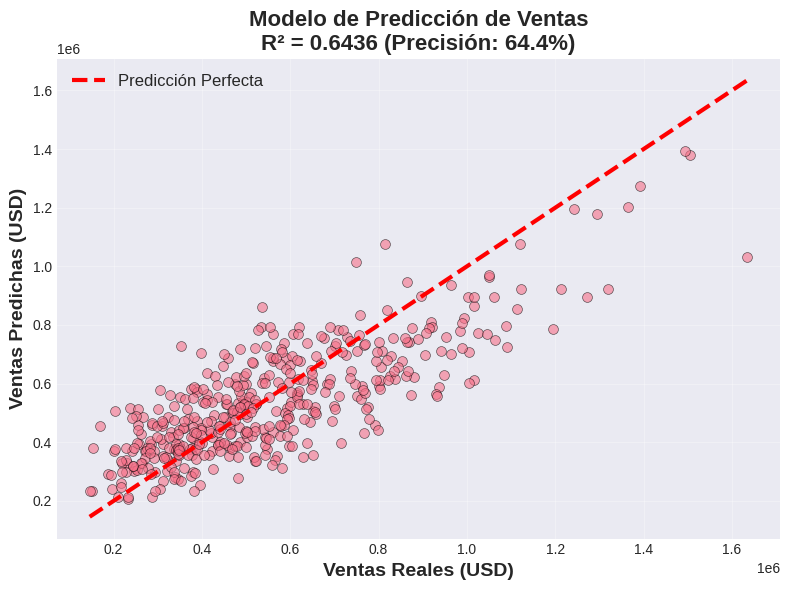

In [316]:
import matplotlib.pyplot as plt
import numpy as np
# 1. GRÁFICO REAL VS PREDICHO (Principal)
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred, alpha=0.6, s=50, edgecolor='black', linewidth=0.5)
# Línea de predicción perfecta
min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())
plt.plot([min_val, max_val], [min_val, max_val],
'r--', linewidth=3, label='Predicción Perfecta')
plt.xlabel('Ventas Reales (USD)', fontsize=14, fontweight='bold')
plt.ylabel('Ventas Predichas (USD)', fontsize=14, fontweight='bold')
plt.title(f'Modelo de Predicción de Ventas\nR² = {r2:.4f} (Precisión: {r2*100:.1f}%)',
fontsize=16, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('grafico_real_vs_predicho.png', dpi=300, bbox_inches='tight')
plt.show()


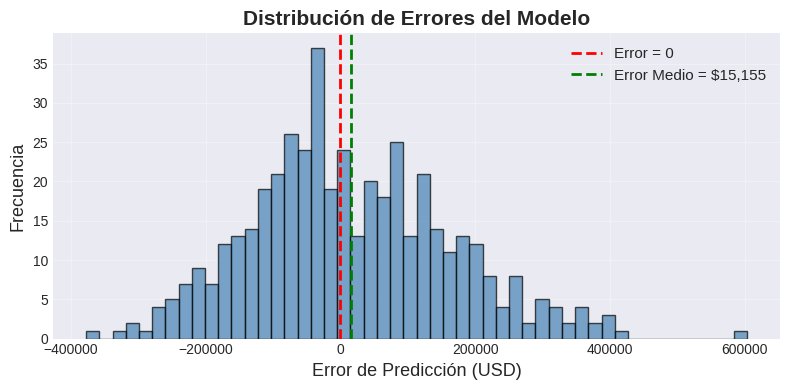

In [317]:
# 2. DISTRIBUCIÓN DE ERRORES
errores = y_test - y_test_pred
plt.figure(figsize=(8, 4))
plt.hist(errores, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Error = 0')
plt.axvline(x=errores.mean(), color='green', linestyle='--', linewidth=2,
label=f'Error Medio = ${errores.mean():,.0f}')
plt.xlabel('Error de Predicción (USD)', fontsize=13)
plt.ylabel('Frecuencia', fontsize=13)
plt.title('Distribución de Errores del Modelo', fontsize=15, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('distribucion_errores.png', dpi=300, bbox_inches='tight')
plt.show()


In [318]:
# 3. TABLA RESUMEN PARA PPT
print("\n" + "="*70)
print("TABLA PARA COPIAR A POWERPOINT")
print("="*70)
print(f"R² (Precisión): {r2*100:.1f}%")
print(f"MAE (Error promedio): ${mae:,.0f}")
print(f"RMSE: ${rmse:,.0f}")
print(f"Predicciones acertadas: {int(r2*100)} de cada 100")
print("="*70)


TABLA PARA COPIAR A POWERPOINT
R² (Precisión): 64.4%
MAE (Error promedio): $118,915
RMSE: $150,066
Predicciones acertadas: 64 de cada 100


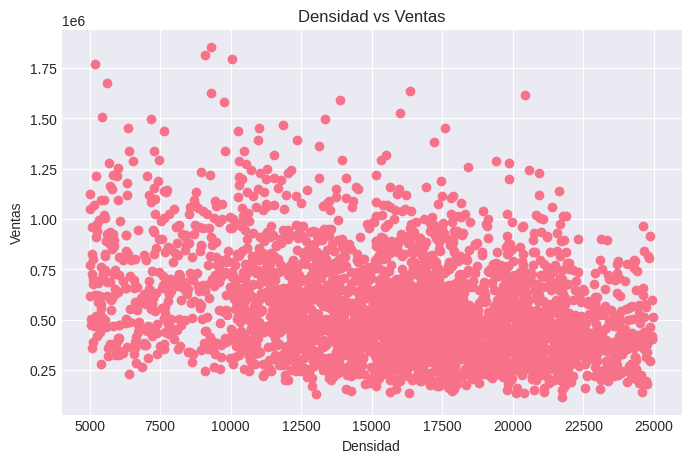

In [319]:
plt.figure(figsize=(8,5))
plt.scatter(df["Densidad_Poblacional_Hab_Km2"],
            df["Ventas_Anuales_Totales_USD"])
plt.xlabel("Densidad")
plt.ylabel("Ventas")
plt.title("Densidad vs Ventas")
plt.show()


In [320]:
# Importar Random Forest
from sklearn.ensemble import RandomForestRegressor

In [321]:
# Crear modelo Random Forest
modelo_rf = RandomForestRegressor(
n_estimators=100, # 100 árboles de decisión
max_depth=15, # Profundidad máxima
min_samples_split=5, # Mínimo 5 muestras para dividir
random_state=42, # Reproducibilidad
n_jobs=-1 # Usar todos los cores del CPU
)
print("■ Modelo Random Forest creado")
print(f" Configuración: {modelo_rf}")


■ Modelo Random Forest creado
 Configuración: RandomForestRegressor(max_depth=15, min_samples_split=5, n_jobs=-1,
                      random_state=42)


In [322]:
# Entrenar el modelo
print("■ Entrenando Random Forest...")
modelo_rf.fit(X_train, y_train)
print("■ Entrenamiento completado")
# Ver información del entrenamiento
print(f"\n■ Información del modelo entrenado:")
print(f" - Número de árboles: {modelo_rf.n_estimators}")
print(f" - Número de features: {X_train.shape[1]}")
print(f" - Registros de entrenamiento: {X_train.shape[0]}")

■ Entrenando Random Forest...
■ Entrenamiento completado

■ Información del modelo entrenado:
 - Número de árboles: 100
 - Número de features: 32
 - Registros de entrenamiento: 2101


In [323]:
# Hacer predicciones en el conjunto de TEST
print("■ Realizando predicciones...")
y_test_pred_rf = modelo_rf.predict(X_test)
print(f"■ Predicciones completadas")
print(f" Total de predicciones: {len(y_test_pred_rf)}")
# Ver las primeras 5 predicciones
print("\n■ Primeras 5 predicciones:")
comparacion = pd.DataFrame({
'Real': y_test.values[:5],
'Predicho': y_test_pred_rf[:5],
'Diferencia': y_test.values[:5] - y_test_pred_rf[:5]
})
print(comparacion.round(0))


■ Realizando predicciones...
■ Predicciones completadas
 Total de predicciones: 450

■ Primeras 5 predicciones:
      Real  Predicho  Diferencia
0   592612  691430.0    -98818.0
1   319906  322187.0     -2281.0
2   521316  574901.0    -53585.0
3  1088128  674626.0    413502.0
4   436150  457925.0    -21775.0


In [324]:
# Calcular métricas
mae_rf = mean_absolute_error(y_test, y_test_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_test_pred_rf))
r2_rf = r2_score(y_test, y_test_pred_rf)
mape_rf = np.mean(np.abs((y_test - y_test_pred_rf) / y_test)) * 100
# Mostrar resultados
print("="*70)
print("■ EVALUACIÓN DEL MODELO RANDOM FOREST")
print("="*70)
print(f"MAE (Error Absoluto Medio): ${mae_rf:>12,.0f}")
print(f"RMSE (Raíz Error Cuadrático): ${rmse_rf:>12,.0f}")
print(f"R² (Coef. Determinación): {r2_rf:>12.4f} ({r2_rf*100:.2f}%)")
print(f"MAPE (Error Porcentual): {mape_rf:>12.2f}%")
print("="*70)
# Interpretación automática
if r2_rf > 0.80:
    print("\n■ ¡EXCELENTE! R² > 80% - Modelo muy preciso")
elif r2_rf > 0.70:
    print("\n■ BUENO: R² > 70% - Modelo confiable")
elif r2_rf > 0.60:
    print("\n■■ ACEPTABLE: R² > 60% - Se puede mejorar")
else:
    print("\n■ BAJO: R² < 60% - Necesita mejoras")

■ EVALUACIÓN DEL MODELO RANDOM FOREST
MAE (Error Absoluto Medio): $      78,632
RMSE (Raíz Error Cuadrático): $     102,540
R² (Coef. Determinación):       0.8336 (83.36%)
MAPE (Error Porcentual):        15.61%

■ ¡EXCELENTE! R² > 80% - Modelo muy preciso


In [325]:
# Comparación directa
print("\n" + "="*70)
print("■ COMPARACIÓN: KNN vs RANDOM FOREST")
print("="*70)
# (las calculaste en el código anterior como: mae, rmse, r2)
comparacion_modelos = pd.DataFrame({
'Métrica': ['MAE', 'RMSE', 'R²'],
'KNN': [mae, rmse, r2], # Tus métricas anteriores
'Random Forest': [mae_rf, rmse_rf, r2_rf]
})
print(comparacion_modelos.to_string(index=False))
# Calcular mejora
mejora_r2 = ((r2_rf - r2) / r2) * 100
mejora_mae = ((mae - mae_rf) / mae) * 100
print("\n" + "-"*70)
print("■ MEJORAS:")
print(f" R² mejoró: {r2:.4f} → {r2_rf:.4f} (+{mejora_r2:.1f}%)的发展")
print(f" MAE mejoró: ${mae:,.0f} → ${mae_rf:,.0f} (-{mejora_mae:.1f}%) de")
print("-"*70)
if r2_rf > r2:
    print("\n■ GANADOR: Random Forest es mejor que KNN")
else:
    print("\n■■ KNN sigue siendo mejor en este caso")


■ COMPARACIÓN: KNN vs RANDOM FOREST
Métrica           KNN  Random Forest
    MAE 118914.670694   78632.223932
   RMSE 150066.257126  102540.392988
     R²      0.643560       0.833578

----------------------------------------------------------------------
■ MEJORAS:
 R² mejoró: 0.6436 → 0.8336 (+29.5%)的发展
 MAE mejoró: $118,915 → $78,632 (-33.9%) de
----------------------------------------------------------------------

■ GANADOR: Random Forest es mejor que KNN


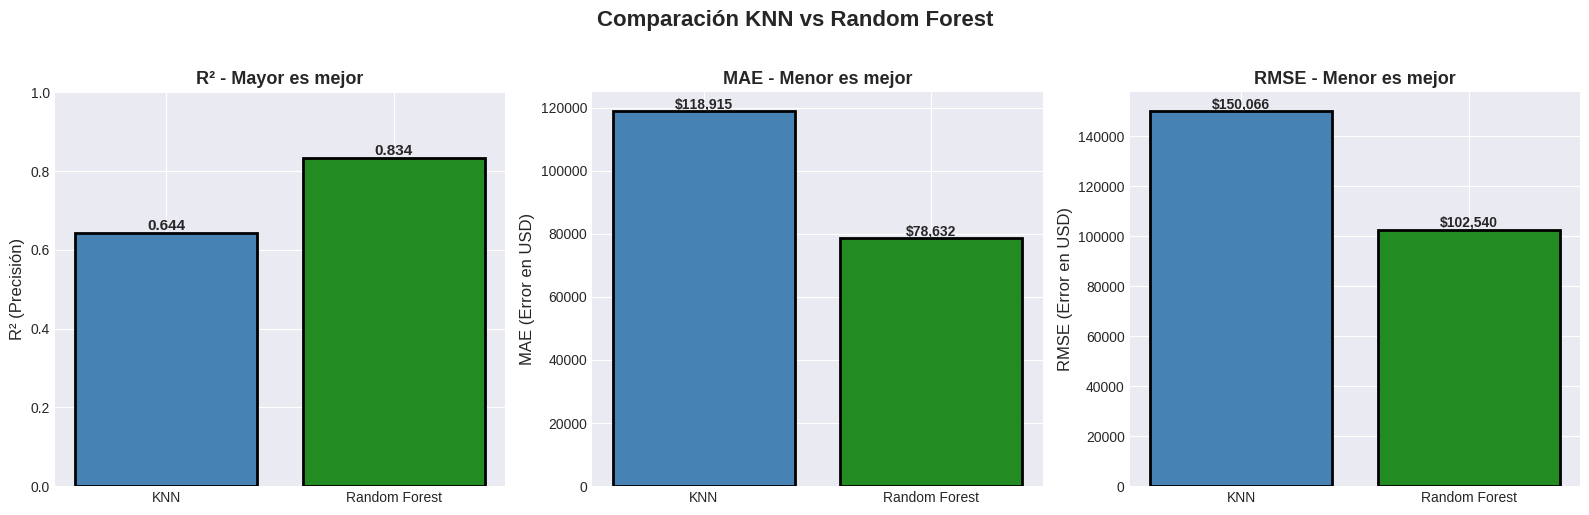

In [326]:
# Gráfico de barras comparativo
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
# R²
axes[0].bar(['KNN', 'Random Forest'], [r2, r2_rf],
color=['steelblue', 'forestgreen'],
edgecolor='black', linewidth=2)
axes[0].set_ylabel('R² (Precisión)', fontsize=12)
axes[0].set_title('R² - Mayor es mejor', fontsize=13, fontweight='bold')
axes[0].set_ylim(0, 1)
for i, v in enumerate([r2, r2_rf]):
    axes[0].text(i, v, f'{v:.3f}', ha='center', va='bottom',
fontsize=11, fontweight='bold')
    # MAE
axes[1].bar(['KNN', 'Random Forest'], [mae, mae_rf],
color=['steelblue', 'forestgreen'],
edgecolor='black', linewidth=2)
axes[1].set_ylabel('MAE (Error en USD)', fontsize=12)
axes[1].set_title('MAE - Menor es mejor', fontsize=13, fontweight='bold')
for i, v in enumerate([mae, mae_rf]):
    axes[1].text(i, v, f'${v:,.0f}', ha='center', va='bottom',
fontsize=10, fontweight='bold')
# RMSE
axes[2].bar(['KNN', 'Random Forest'], [rmse, rmse_rf],
color=['steelblue', 'forestgreen'],
edgecolor='black', linewidth=2)
axes[2].set_ylabel('RMSE (Error en USD)', fontsize=12)
axes[2].set_title('RMSE - Menor es mejor', fontsize=13, fontweight='bold')
for i, v in enumerate([rmse, rmse_rf]):
    axes[2].text(i, v, f'${v:,.0f}', ha='center', va='bottom',
fontsize=10, fontweight='bold')
plt.suptitle('Comparación KNN vs Random Forest',
fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

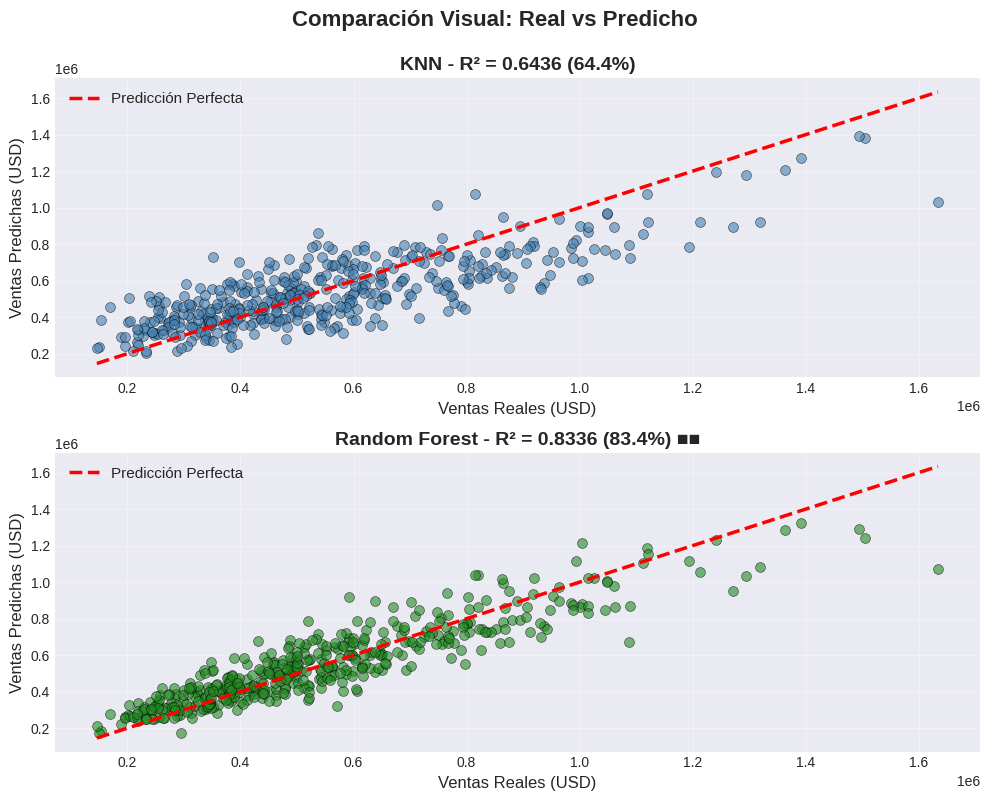


■ Interpretación:
 - Puntos cerca de la línea roja = buenas predicciones
 - Random Forest tiene puntos más agrupados cerca de la línea


In [327]:
# Gráfico Real vs Predicho
plt.figure(figsize=(10, 8))
# Subplot 1: KNN
plt.subplot(2, 1, 1)
plt.scatter(y_test, y_test_pred, alpha=0.6, s=50,
color='steelblue', edgecolor='black', linewidth=0.5)
min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())
plt.plot([min_val, max_val], [min_val, max_val],
'r--', linewidth=2.5, label='Predicción Perfecta')
plt.xlabel('Ventas Reales (USD)', fontsize=12)
plt.ylabel('Ventas Predichas (USD)', fontsize=12)
plt.title(f'KNN - R² = {r2:.4f} ({r2*100:.1f}%)',
fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
# Subplot 2: Random Forest
plt.subplot(2, 1, 2)
plt.scatter(y_test, y_test_pred_rf, alpha=0.6, s=50,
color='forestgreen', edgecolor='black', linewidth=0.5)
plt.plot([min_val, max_val], [min_val, max_val],
'r--', linewidth=2.5, label='Predicción Perfecta')
plt.xlabel('Ventas Reales (USD)', fontsize=12)
plt.ylabel('Ventas Predichas (USD)', fontsize=12)
plt.title(f'Random Forest - R² = {r2_rf:.4f} ({r2_rf*100:.1f}%) ■■',
fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.suptitle('Comparación Visual: Real vs Predicho',
fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()
print("\n■ Interpretación:")
print(" - Puntos cerca de la línea roja = buenas predicciones")
print(" - Random Forest tiene puntos más agrupados cerca de la línea")

■ TOP 10 VARIABLES MÁS IMPORTANTES
                       Variable  Importancia
Inversion_Marketing_Mensual_USD     0.643865
                 Rubro_Farmacia     0.074139
         Distancia_Ancla_Metros     0.064187
            Ticket_Promedio_USD     0.043666
               Venta_Online_Pct     0.020257
           Alquiler_Mensual_USD     0.020012
               Antiguedad_Anios     0.019220
                  Superficie_m2     0.015254
         Transito_Peatonal_Pico     0.014855
   Densidad_Poblacional_Hab_Km2     0.013895


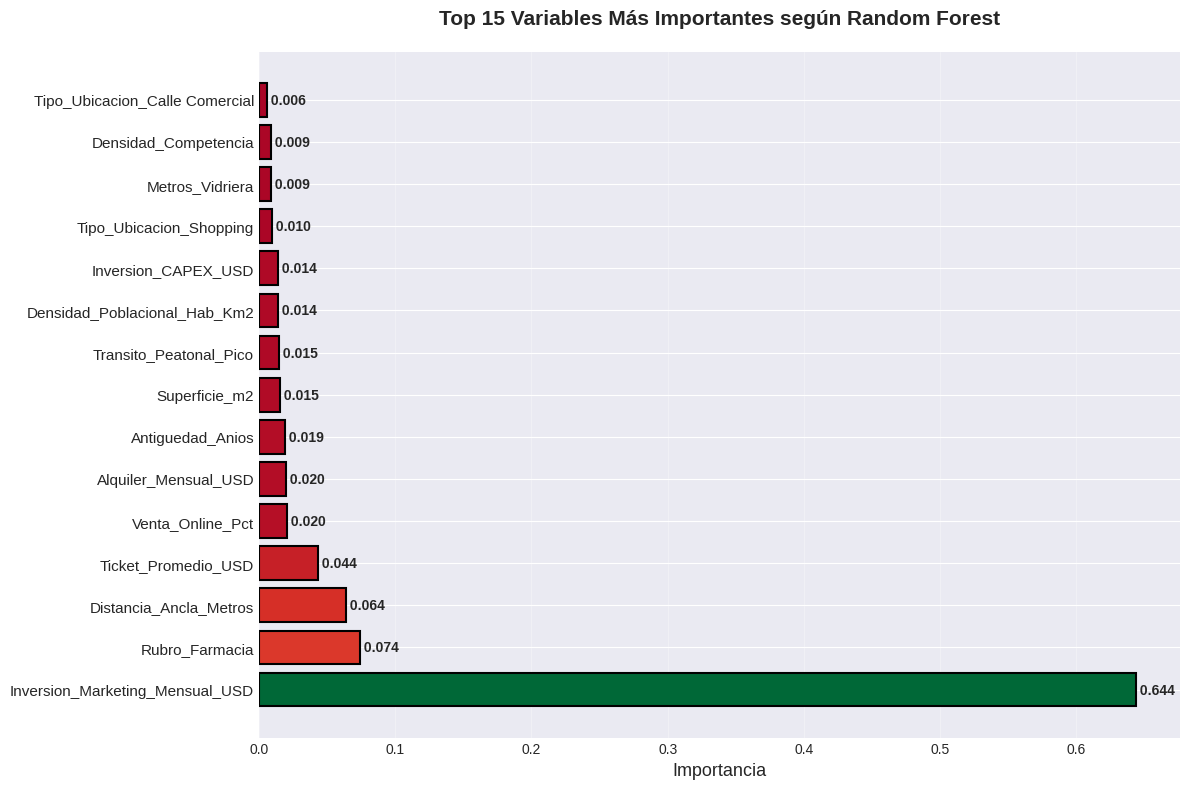


■ Interpretación:
 - Valores más altos = variables más importantes para predecir
 - Random Forest usa estas variables más frecuentemente


In [328]:
# Extraer importancia de variables
importancias = pd.DataFrame({
'Variable': features,
'Importancia': modelo_rf.feature_importances_
}).sort_values('Importancia', ascending=False)
# Mostrar top 10
print("="*70)
print("■ TOP 10 VARIABLES MÁS IMPORTANTES")
print("="*70)
print(importancias.head(10).to_string(index=False))
print("="*70)
# Gráfico de importancia
plt.figure(figsize=(12, 8))
top_15 = importancias.head(15)
colores = plt.cm.RdYlGn(top_15['Importancia'] / top_15['Importancia'].max())
barras = plt.barh(range(len(top_15)), top_15['Importancia'],
color=colores, edgecolor='black', linewidth=1.5)
plt.yticks(range(len(top_15)), top_15['Variable'], fontsize=11)
plt.xlabel('Importancia', fontsize=13)
plt.title('Top 15 Variables Más Importantes según Random Forest',
fontsize=15, fontweight='bold', pad=20)
plt.grid(True, alpha=0.3, axis='x')
# Agregar valores
for i, (idx, row) in enumerate(top_15.iterrows()):
    plt.text(row['Importancia'], i, f' {row["Importancia"]:.3f}',
    va='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()
print("\n■ Interpretación:")
print(" - Valores más altos = variables más importantes para predecir")
print(" - Random Forest usa estas variables más frecuentemente")

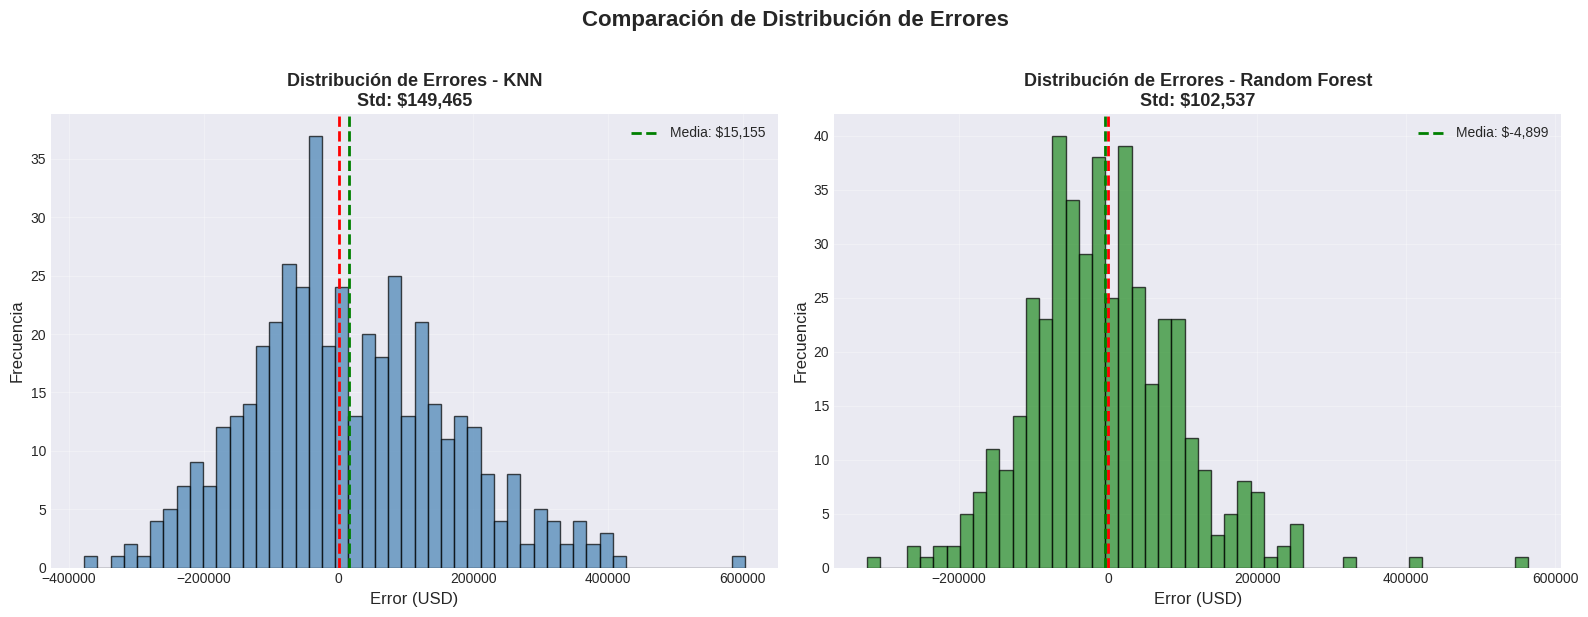


■ ESTADÍSTICAS DE ERRORES
                                      KNN        Random Forest
----------------------------------------------------------------------
Error medio          $             15,155 $             -4,899
Desv. estándar       $            149,465 $            102,537
Error máximo         $            603,539 $            563,493

■ Random Forest tiene errores más consistentes (menor desviación)


In [329]:
# Calcular errores (residuos)
errores_knn = y_test - y_test_pred
errores_rf = y_test - y_test_pred_rf
# Gráfico comparativo de errores
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# KNN
axes[0].hist(errores_knn, bins=50, edgecolor='black',
alpha=0.7, color='steelblue')
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0].axvline(x=errores_knn.mean(), color='green', linestyle='--',
linewidth=2, label=f'Media: ${errores_knn.mean():,.0f}')
axes[0].set_xlabel('Error (USD)', fontsize=12)
axes[0].set_ylabel('Frecuencia', fontsize=12)
axes[0].set_title(f'Distribución de Errores - KNN\nStd: ${errores_knn.std():,.0f}',
fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
# Random Forest
axes[1].hist(errores_rf, bins=50, edgecolor='black',
alpha=0.7, color='forestgreen')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].axvline(x=errores_rf.mean(), color='green', linestyle='--',
linewidth=2, label=f'Media: ${errores_rf.mean():,.0f}')
axes[1].set_xlabel('Error (USD)', fontsize=12)
axes[1].set_ylabel('Frecuencia', fontsize=12)
axes[1].set_title(f'Distribución de Errores - Random Forest\nStd: ${errores_rf.std():,.0f}',
fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.suptitle('Comparación de Distribución de Errores',
fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
# Estadísticas de errores
print("\n" + "="*70)
print("■ ESTADÍSTICAS DE ERRORES")
print("="*70)
print(f"{'':20s} {'KNN':>20s} {'Random Forest':>20s}")
print("-"*70)
print(f"{'Error medio':20s} ${errores_knn.mean():>19,.0f} ${errores_rf.mean():>19,.0f}")
print(f"{'Desv. estándar':20s} ${errores_knn.std():>19,.0f} ${errores_rf.std():>19,.0f}")
print(f"{'Error máximo':20s} ${errores_knn.abs().max():>19,.0f} ${errores_rf.abs().max():>19,.0f}")
print("="*70)
if errores_rf.std() < errores_knn.std():
    print("\n■ Random Forest tiene errores más consistentes (menor desviación)")

In [330]:
from sklearn.model_selection import cross_val_score
print("■ Ejecutando validación cruzada (5-fold)...")
print(" Esto puede tomar 1-2 minutos...")
# Validación cruzada con 5 particiones
cv_scores = cross_val_score(
modelo_rf,
X_train,
y_train,
cv=5, # 5 particiones
scoring='r2', # Métrica: R²
n_jobs=-1 # Usar todos los cores
)
print("\n■ Validación cruzada completada")
print("="*70)
print("■ RESULTADOS DE VALIDACIÓN CRUZADA")
print("="*70)
print(f"R² en cada fold:")
for i, score in enumerate(cv_scores, 1):
    print(f" Fold {i}: {score:.4f}")
print("-"*70)
print(f"R² promedio: {cv_scores.mean():.4f}")
print(f"Desviación std: {cv_scores.std():.4f}")
print("="*70)
if cv_scores.std() < 0.05:
    print("\n■ EXCELENTE: El modelo es muy estable (baja varianza)")
elif cv_scores.std() < 0.10:
    print("\n■ BUENO: El modelo es estable")
else:
    print("\n■■ ALERTA: Alta varianza, el modelo puede ser inestable")
# Comparar con R² de test
diferencia = abs(cv_scores.mean() - r2_rf)
print(f"\nDiferencia con R² test: {diferencia:.4f}")
if diferencia < 0.05:
    print("■ Sin overfitting: CV score \u2248 Test score")

■ Ejecutando validación cruzada (5-fold)...
 Esto puede tomar 1-2 minutos...

■ Validación cruzada completada
■ RESULTADOS DE VALIDACIÓN CRUZADA
R² en cada fold:
 Fold 1: 0.8295
 Fold 2: 0.8113
 Fold 3: 0.8066
 Fold 4: 0.7846
 Fold 5: 0.7806
----------------------------------------------------------------------
R² promedio: 0.8025
Desviación std: 0.0180

■ EXCELENTE: El modelo es muy estable (baja varianza)

Diferencia con R² test: 0.0311
■ Sin overfitting: CV score ≈ Test score


In [331]:
from sklearn.model_selection import GridSearchCV
print("■ Buscando mejores hiperparámetros...")
print(" ■■ Esto puede tomar 5-10 minutos...")
# Definir parámetros a probar
param_grid = {
'n_estimators': [100, 150, 200],
'max_depth': [10, 15, 20],
'min_samples_split': [2, 5, 10]
}
# Grid Search
grid_search = GridSearchCV(
RandomForestRegressor(random_state=42, n_jobs=-1),
param_grid,
cv=3, # 3 folds para ser más rápido
scoring='r2',
n_jobs=-1,
verbose=1
)
grid_search.fit(X_train, y_train)
print("\n■ Búsqueda completada")
print("="*70)
print("■ MEJORES HIPERPARÁMETROS ENCONTRADOS:")
print("="*70)
for param, value in grid_search.best_params_.items():
    print(f" {param:20s}: {value}")
print(f"\n R² en validación: {grid_search.best_score_:.4f}")
print("="*70)
# Usar el mejor modelo
modelo_rf_optimizado = grid_search.best_estimator_
# Evaluar en test
y_test_pred_opt = modelo_rf_optimizado.predict(X_test)
r2_opt = r2_score(y_test, y_test_pred_opt)
mae_opt = mean_absolute_error(y_test, y_test_pred_opt)
print("\n■ COMPARACIÓN:")
print(f" RF original: R² = {r2_rf:.4f}")
print(f" RF optimizado: R² = {r2_opt:.4f}")
print(f" Mejora: {(r2_opt - r2_rf)*100:+.2f} puntos porcentuales")
if r2_opt > r2_rf:
    print("\n■ ¡Optimización exitosa!")
    modelo_rf = modelo_rf_optimizado
    r2_rf = r2_opt
    mae_rf = mae_opt

■ Buscando mejores hiperparámetros...
 ■■ Esto puede tomar 5-10 minutos...
Fitting 3 folds for each of 27 candidates, totalling 81 fits

■ Búsqueda completada
■ MEJORES HIPERPARÁMETROS ENCONTRADOS:
 max_depth           : 15
 min_samples_split   : 2
 n_estimators        : 150

 R² en validación: 0.8030

■ COMPARACIÓN:
 RF original: R² = 0.8336
 RF optimizado: R² = 0.8367
 Mejora: +0.31 puntos porcentuales

■ ¡Optimización exitosa!


In [332]:
print(df.dtypes)

ID_Local                             int64
Rubro                               object
Superficie_m2                        int64
Metros_Vidriera                    float64
Inversion_CAPEX_USD                  int64
Antiguedad_Anios                   float64
Inversion_Marketing_Mensual_USD      int64
Alquiler_Mensual_USD                 int64
Transito_Peatonal_Pico               int64
Puntos_Interes_Proximos              int64
Distancia_Ancla_Metros               int64
Ubicacion_Esquina                    int64
Nivel_Socioeconomico                object
Densidad_Poblacional_Hab_Km2         int64
Tipo_Ubicacion                      object
Densidad_Competencia                 int64
Venta_Online_Pct                   float64
Ticket_Promedio_USD                  int64
Posicionamiento_Precio              object
Margen_EBITDA_Pct                  float64
Ventas_Anuales_Totales_USD           int64
dtype: object
